# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [8]:
# importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:

# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')


In [10]:
# mostrar las primeras 5 filas de plans
plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [11]:
# mostrar las primeras 5 filas de users
users.head(-5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN
...,...,...,...,...,...,...,...,...
3990,13990,Mateo,Gomez,-999,Bogotá,2024-12-28 12:51:18.769692432,Basico,NaN
3991,13991,Mateo,Lopez,26,NaN,2024-12-28 19:25:36.684171056,Basico,NaN
3992,13992,Ana,Torres,24,Medellín,2024-12-29 01:59:54.598649664,Premium,NaN
3993,13993,Carlos,Gomez,67,Cali,2024-12-29 08:34:12.513128288,Basico,"1,73172E+18"


In [12]:
# mostrar las primeras 5 filas de usage
usage.head(-5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN
...,...,...,...,...,...,...
39990,39991,10817,call,2024-06-29 23:01:21.272031800,3.93,NaN
39991,39992,13508,call,2024-06-29 23:07:52.241806044,1.92,NaN
39992,39993,12152,call,2024-06-29 23:14:23.211580288,4.52,NaN
39993,39994,11372,call,2024-06-29 23:20:54.181354532,3.13,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [13]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [14]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [15]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [16]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [17]:

# cantidad de nulos para users
print(users.isna().sum())
    # Cantidad de valores nulos)
print()
print(users.isna().mean())
    # Proporción de valores nulos)


user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [18]:

# cantidad de nulos para usage
print(usage.isna().sum())
    # Cantidad de valores nulos)
print()
print(usage.isna().mean())
    # Proporción de valores nulos)



id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
  
**En el dataset de USER tenemos nulos en:**
**- city → 11.7% nulos (los imputamos)**
Esto nos afecta, ya que entre nuestros análisis queremos segmentar a nuestros clientes y esta segmentación podría ser por país.
**- churn_date → 88% nulos (Los ignoramos o transformamos)**
Nota: Estos nulos se pueden marcar **"cliente activo"**


**En el dataset de USAGE tenemos nulos en:**
**duration → 55% nulos (IMPUTAR + CREAR FLAG)**
Puede que el nulo en esta col sea porque no hubo llamada, así que cuando hagamos una agrupación por texto y por llamadas, que sea nulo no nos va a afectar.

**length → 44% nulos (IMPUTAR + CREAR FLAG)**
Puede que el nulo en esta col sea porque no hubo texto, así que cuando hagamos una agrupación por texto y por llamadas, que sea nulo no nos va a afectar.

**date → muy pocos nulos**
Podríamos borrar porque son muy pocos nulos.


### Detección de valores inválidos y sentinel
### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [19]:
# explorar columnas numéricas de users
columnas_numericas = ['user_id', 'age']

print('columnas numéricas de users')
print(users[columnas_numericas].describe())


columnas numéricas de users
            user_id          age
count   4000.000000  4000.000000
mean   11999.500000    33.739750
std     1154.844867   123.232257
min    10000.000000  -999.000000
25%    10999.750000    32.000000
50%    11999.500000    47.000000
75%    12999.250000    63.000000
max    13999.000000    79.000000


- La columna `user_id` 
Podemos ver que en la columna de **User_id** no tenemos nulos ni valores inválidos que puedan dañar nuestro análisis. La media y la mediana son iguales y la diferencia entre el 75% y el máximo es razonable.

- La columna `age`
En columna **age** podemos ver que hay valores atípicos presentes (sentinel corrupto) 

In [20]:
# explorar columnas numéricas de usage
columnas_numericas = ['user_id', 'id']

print('columnas numéricas de usage')
print(usage[columnas_numericas].describe())

columnas numéricas de usage
            user_id           id
count  40000.000000  40000.00000
mean   12002.405975  20000.50000
std     1157.279564  11547.14972
min    10000.000000      1.00000
25%    10996.000000  10000.75000
50%    12013.000000  20000.50000
75%    13005.000000  30000.25000
max    13999.000000  40000.00000


- Las columnas `id` y `user_id`...Haz doble clic en este bloque y escribe qué ves.
- Las columnas no tienen comportamientos extraños; **Id** podríamos eliminarla de nuestro análisis, ya que parece un conteo de las filas registradas.
- En **user_id** podemos analizar que hay clientes repetidos y la utilizaremos como llave para unir las dos tablas.

In [21]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']

print("Frecuencia absoluta City")
print(users['city'].value_counts())

print("\nFrecuencia relativa City")
print(users['city'].value_counts(normalize=True))
print()
print("Frecuencia absoluta Plan")
print(users['plan'].value_counts())

print("\nFrecuencia relativa Plan")
print(users['plan'].value_counts(normalize=True))



Frecuencia absoluta City
Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

Frecuencia relativa City
Bogotá      0.228830
CDMX        0.206740
Medellín    0.174455
GDL         0.127443
Cali        0.120079
MTY         0.115265
?           0.027188
Name: city, dtype: float64

Frecuencia absoluta Plan
Basico     2595
Premium    1405
Name: plan, dtype: int64

Frecuencia relativa Plan
Basico     0.64875
Premium    0.35125
Name: plan, dtype: float64


- La columna `city`
✔ distribución equilibrada
✔ pequeño problema de calidad ("?") transformar a Unknown
✔ buena base para segmentación geográfica

- La columna `plan`
Data sin problema; vemos una mayoría en plan Básico. Podríamos analizar si geográficamente, por precio o por segmentación para mejoras en marketing y en precio.

No se detectan sentinels en variables categóricas principales
Vemos que la mayoría de los clientes están en plan Basio

In [22]:
# explorar columna categórica de usage
usage['type'] # completa el código

print("Frecuencia absoluta type")
print(usage['type'].value_counts())

print("\nFrecuencia relativa type")
print(usage['type'].value_counts(normalize=True))

Frecuencia absoluta type
text    22092
call    17908
Name: type, dtype: int64

Frecuencia relativa type
text    0.5523
call    0.4477
Name: type, dtype: float64


- La columna `type`
  No se detectan errores en la columna.
  Vemos que la frecuencia de los datos se concentra en text.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  

En la columna **age** se encontraron valores como -999, los cuales representan datos mal codificados y no valores reales.
En la columna **city** se encontró el valor “?”, que representa información desconocida o no registrada.

En ambos casos, estos valores no deben eliminarse directamente, sino ser transformados a valores nulos o categorías como “Unknown”, para preservar la información del dataset y evitar sesgos en el análisis.



### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [23]:

# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'])


In [24]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'])

In [25]:
# Revisar los años presentes en `reg_date` de users
sorted(users['reg_date'].dt.year.unique())

[2022, 2023, 2024, 2026]


En `reg_date`, vemos que estan datos del 2022 al 2026 pero nos hace falta el 2025. 
Pero no es algo que nos afecte en nuetro analisis ya que solo analizaremos los datos el 2024



In [26]:
# Revisar los años presentes en `date` de usage
sorted(usage['date'].dt.year.unique())

[2024.0, nan]

En `date`, vemos que el año está 2024 y tenemos también valores nulos  
Basaremos el análisis en estas fechas eliminando los 50 datos con este valor nulo.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
  Sí, tenemos años pasados y años sin transcurrir, haremos una segmentacion de los datos solo para analizar el 2024.
- ¿Qué harías con ellas?
  Los dejamos en el data original y creamos un data nuevo solo del 2024 limpio.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [27]:
# Reemplazar -999 por la mediana de age
age_mediana = users.loc[users['age'] != -999, 'age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [28]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', np.nan)

# Verificar cambios
users['city'].isna().sum()

565

In [29]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'] > pd.Timestamp.today(), 'reg_date'] = pd.NaT

# Verificar cambios
users['reg_date'].isna().sum()

0

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [30]:

# Verificación MAR en usage (Missing At Random) para duration
usage['duration'].isna().groupby(usage['type']).mean().sort_values(ascending=False)



type
text    0.999276
call    0.000000
Name: duration, dtype: float64

In [31]:
# Verificación MAR en usage (Missing At Random) para length
usage['length'].isna().groupby(usage['type']).mean().sort_values(ascending=False)

type
call    0.99933
text    0.00000
Name: length, dtype: float64

Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`
Los valores nulos observados en las variables duration y length no representan necesariamente datos faltantes. Al analizar la variable type, se observa que cada registro corresponde a un tipo específico de interacción (llamada o mensaje). Por lo tanto, los nulos son estructurales: la duración solo aplica a llamadas y la longitud solo aplica a mensajes. En consecuencia, estos valores no deben imputarse ni eliminarse, sino tratarse como ausencia esperada de información para ese tipo de registro.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [32]:

# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby('user_id').agg({
    'is_text': 'sum',
    'is_call': 'sum',
    'duration': 'sum',
    'length': 'sum'
}).reset_index()

# observar resultado
usage_agg.head(3)


,user_id,is_text,is_call,duration,length
0,10000,7,3,23.70,258.0
1,10001,5,10,33.18,226.0
2,10002,5,2,10.74,225.0


In [33]:

# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    'is_text': 'cant_mensajes',
    'is_call': 'cant_llamadas',
    'duration': 'cant_minutos_llamada'
})

# observar resultado
usage_agg.head(3)


,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada,length
0,10000,7,3,23.70,258.0
1,10001,5,10,33.18,226.0
2,10002,5,2,10.74,225.0


In [34]:

# Combinar la tabla agregada con el dataset de usuarios

user_profile = users.merge(usage_agg, on='user_id', how='left')

user_profile.head(5)


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,length
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,258.0
1,10001,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,226.0
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,225.0
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,530.0
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,229.0


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.


**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.


In [35]:
# Resumen estadístico de las columnas numéricas
user_profile[['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054
std,17.689919,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [36]:

# Distribución porcentual del tipo de plan
(user_profile['plan']
 .value_counts(normalize=True)
 .mul(100)
 .round(2))


Basico     64.88
Premium    35.12
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

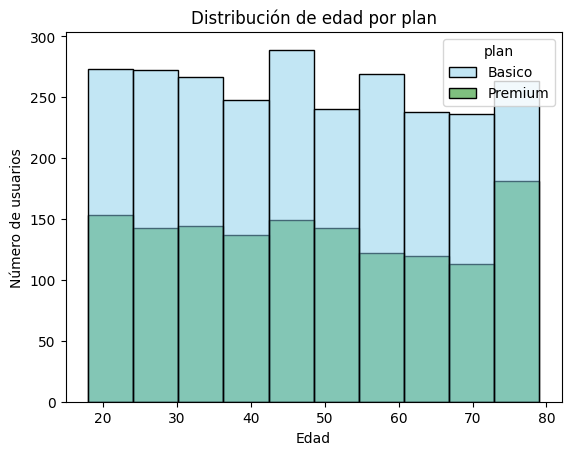

In [37]:
# Histograma para visualizar la edad (age)

sns.histplot(
    data=user_profile,
    x='age',
    hue='plan',
    palette=['skyblue', 'green'],
    bins=10
)

plt.title('Distribución de edad por plan')
plt.xlabel('Edad')
plt.ylabel('Número de usuarios')
plt.show()


💡Insights: 
- Distribución
El tipo de plan no está explicado por la edad del cliente, lo que sugiere que la segmentación del producto no es demográfica sino probablemente conductual (uso) o económica.
Solo se ve un pequeño incremento en el rango de 70 a 80 años donde crece un poco el número de usuarios premium.

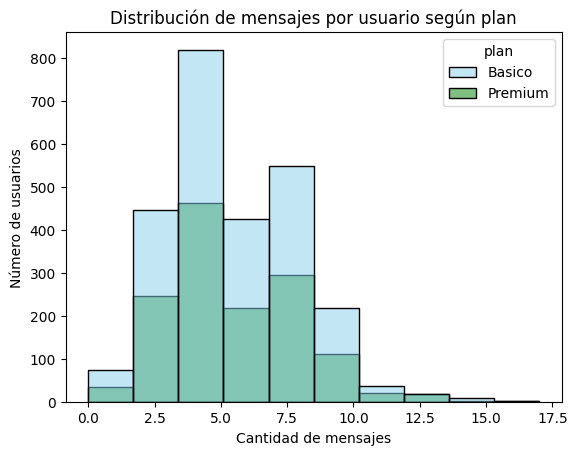

In [38]:
# Histograma para visualizar la cant_mensajes
sns.histplot(
    data=user_profile,
    x='cant_mensajes',
    hue='plan',
    palette=['skyblue', 'green'],
    bins=10
)

plt.title('Distribución de mensajes por usuario según plan')
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Número de usuarios')

plt.show()


La mayoría de los usuarios envía una cantidad baja de mensajes (aproximadamente entre 2 y 5), lo que indica un comportamiento de uso ligero en la mensajería.
La distribución está sesgada a la derecha, con algunos usuarios que presentan valores muy altos (outliers), lo que puede influir en el promedio y distorsionar el análisis si no se tratan adecuadamente.
No se observa una diferencia clara en el comportamiento de mensajería entre los usuarios de plan Básico y Premium, lo que sugiere que el tipo de plan no está relacionado directamente con el uso de mensajes.


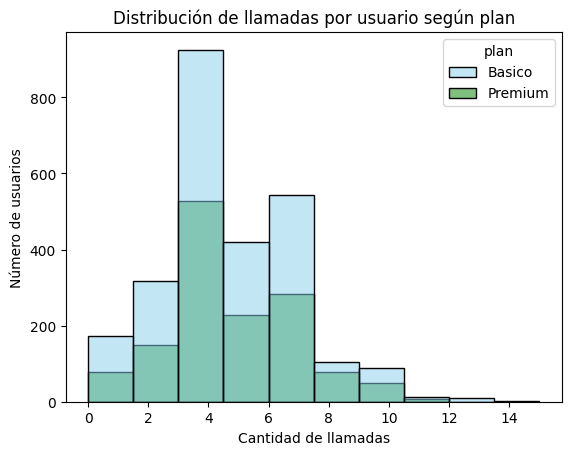

In [39]:
# Histograma para visualizar la cant_llamadas

sns.histplot(
    data=user_profile,
    x='cant_llamadas',
    hue='plan',
    palette=['skyblue', 'green'],
    bins=10
)

plt.title('Distribución de llamadas por usuario según plan')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Número de usuarios')

plt.show()

💡Insights: 
La mayoría de los usuarios envía una cantidad baja de llamadas (aproximadamente entre 3 y 6), lo que indica un comportamiento de uso ligero.
La distribución está sesgada a la derecha, con algunos usuarios que presentan valores muy altos (outliers), lo que puede influir en el promedio y distorsionar el análisis si no se tratan adecuadamente.
No se observa una diferencia clara en el comportamiento de mensajería entre los usuarios de plan Básico y Premium, lo que sugiere que el tipo de plan no está relacionado directamente con el uso de llamadas.

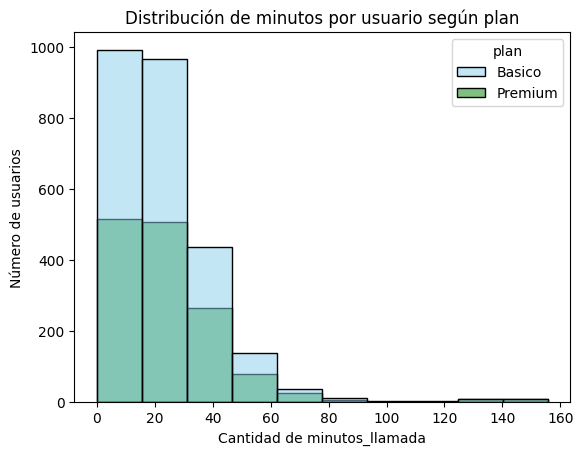

In [40]:
# Histograma para visualizar la cant_minutos_llamada

sns.histplot(
    data=user_profile,
    x='cant_minutos_llamada',
    hue='plan',
    palette=['skyblue', 'green'],
    bins=10
)

plt.title('Distribución de minutos por usuario según plan')
plt.xlabel('Cantidad de minutos_llamada')
plt.ylabel('Número de usuarios')

plt.show()


💡Insights: 
- La mayoría de los usuarios concentra un bajo volumen de minutos de llamada, principalmente entre 0 y 20 minutos, lo que indica un uso ligero del servicio de voz.
La distribución está fuertemente sesgada a la derecha, con algunos usuarios que presentan valores muy altos (outliers), lo que puede afectar el promedio y distorsionar el análisis si no se tratan adecuadamente.
No se observa una diferencia clara entre los planes Básico y Premium en el uso de minutos de llamada, lo que sugiere que el tipo de plan no está relacionado directamente con la intensidad de uso del servicio de llamadas.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

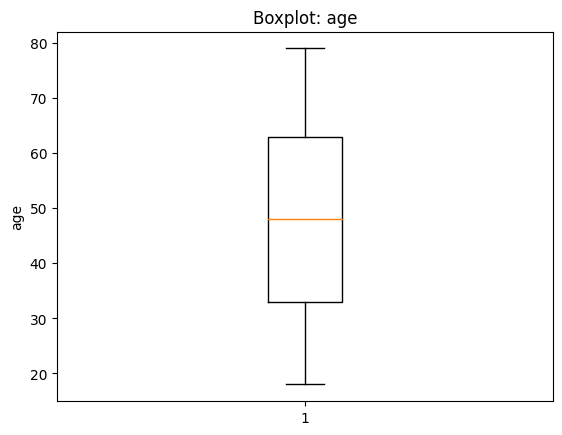

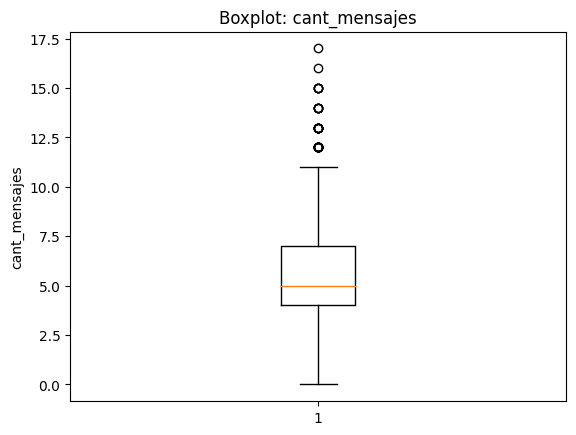

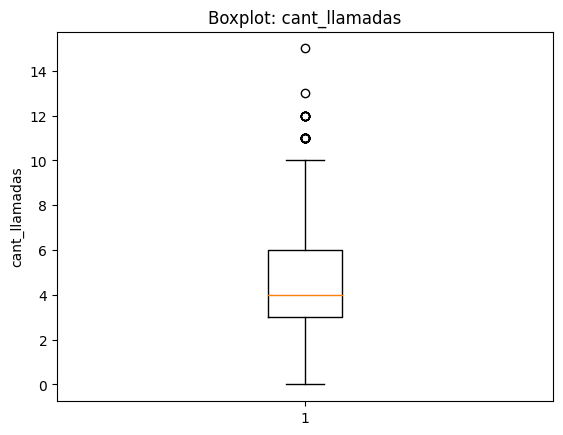

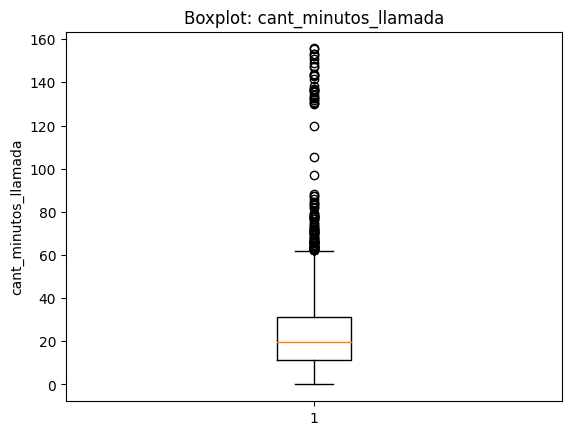

In [42]:
# Visualizando usando BoxPlot 
cols = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in cols:
    plt.figure()
    plt.boxplot(user_profile[col].dropna())
    plt.title(f'Boxplot: {col}')
    plt.ylabel(col)
    plt.show()


💡Insights: 
-Age: No se observan outliers significativos, lo que indica una distribución relativamente estable en la edad de los usuarios.
cant_mensajes: Se identifican outliers hacia la derecha, lo que indica la presencia de usuarios con un uso de mensajería considerablemente más alto que el promedio.
cant_llamadas: Se observan algunos outliers leves, lo que sugiere variaciones moderadas en el número de llamadas entre usuarios.
cant_minutos_llamada: Se presentan outliers más marcados hacia la derecha, indicando usuarios con un consumo de minutos significativamente superior al resto.

In [43]:

# Calcular límites con el método IQR
columnas_limites = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    print(f"\n{col}")
    print("Límite inferior:", lower_bound)
    print("Límite superior:", upper_bound)



age
Límite inferior: -12.0
Límite superior: 108.0

cant_mensajes
Límite inferior: -0.5
Límite superior: 11.5

cant_llamadas
Límite inferior: -1.5
Límite superior: 10.5

cant_minutos_llamada
Límite inferior: -19.322500000000005
Límite superior: 61.8575


In [44]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,age,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054
std,17.689919,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: mantener
- cant_llamadas: mantener
- cant_minutos_llamada: mantener
En las tres variables de uso no se eliminan los outliers, ya que no representan errores de registro, sino distintos niveles de consumo entre usuarios. En un contexto de telecomunicaciones, estos valores extremos son relevantes para la segmentación de clientes y el análisis de rentabilidad.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [46]:
# Crear columna grupo_uso
user_profile['grupo_uso'] = np.select(
    [
        (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5),
        (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10)
    ],
    [
        'Bajo uso',
        'Uso medio'
    ],
    default='Alto uso'
)


In [47]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,length,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,258.0,Uso medio
1,10001,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,226.0,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,225.0,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,530.0,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,229.0,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [48]:
# Crear columna grupo_edad
user_profile['grupo_edad'] = np.select(
    [
        user_profile['age'] < 30,
        user_profile['age'] < 60
    ],
    [
        'Joven',
        'Adulto'
    ],
    default='Adulto Mayor'
)


In [49]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,length,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,258.0,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,226.0,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,225.0,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,530.0,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,229.0,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

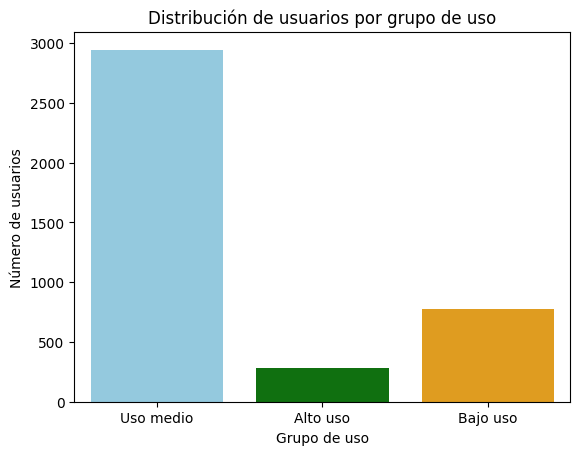

In [52]:
# Visualización de los segmentos por uso
sns.countplot(
    data=user_profile,
    x='grupo_uso',
    palette=['skyblue', 'green', 'orange']
)

plt.title('Distribución de usuarios por grupo de uso')
plt.xlabel('Grupo de uso')
plt.ylabel('Número de usuarios')

plt.show()
plt.show()

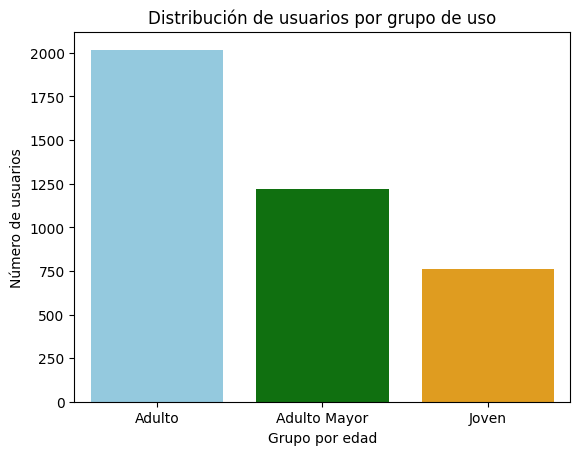

In [51]:
# Visualización de los segmentos por edad
sns.countplot(
    data=user_profile,
    x='grupo_edad',
    palette=['skyblue', 'green', 'orange']
)

plt.title('Distribución de usuarios por grupo de uso')
plt.xlabel('Grupo por edad')
plt.ylabel('Número de usuarios')

plt.show()
plt.show()


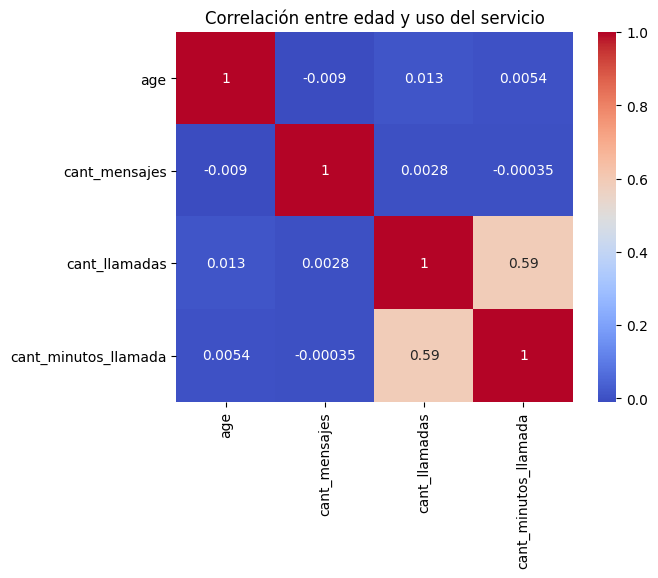

In [55]:
sns.heatmap(
    user_profile[['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlación entre edad y uso del servicio')
plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**


### Análisis ejecutivo


**Insight Ejecutivo para Stakeholders**
1. Problemas identificados en los datos

Durante el proceso de limpieza se identificaron algunos problemas en la calidad de los datos:

**Variables**
1. En la variable city, existían valores no válidos (“?”) que representaban aproximadamente 2.7% de los registros, lo que indicaba datos faltantes o mal registrados.
2. En la variable churn_date, alrededor del 88% de los valores eran nulos, lo cual es esperado en este tipo de datos, ya que la mayoría de los usuarios aún permanecen activos.
3. Se encontraron variables con nulos relacionadas al tipo de producto, mensajes y llamadas, que fueron tratadas según su naturaleza.

*En general, los problemas principales no fueron de corrupción masiva, sino de datos faltantes estructurales.*

**Segmentos de clientes**
**A partir del análisis se identificaron tres segmentos:**
***Por uso***
Bajo uso: usuarios con pocas llamadas y mensajes
Uso medio: mayoría del dataset
Alto uso: usuarios intensivos en llamadas y minutos, baja representación en el data set.

*# La mayoría de los clientes pertenece al segmento de uso medio.*

**Segmento por edad**
Jóvenes (<30): menor participación relativa
Adultos (30–60): segmento dominante
Adultos mayores (>60): menor proporción, pero con comportamiento estable

**Relación edad + uso**
La edad no es un factor determinante en el uso del servicio, por lo que la segmentación de clientes no debería basarse en variables de edad, sino en el comportamiento de uso.

**Los segmentos más valiosos son:**
***Usuarios de alto uso***
Consumen más minutos y llamadas
Potencial mayor generación de ingresos
Posibles candidatos a planes Premium o empresariales

***Usuarios Premium con alto uso***
Aunque menos en cantidad, aportan mayor valor por cliente
En cambio, los usuarios de bajo uso representan la mayor parte de la base, pero menor valor individual.

**4. Patrones de uso extremo (outliers)**

**Se identificaron outliers en:**
cant_mensajes
cant_llamadas
cant_minutos_llamada

**Características:**
Distribución fuertemente sesgada a la derecha
Pequeño grupo de usuarios con consumo extremadamente alto

**Interpretación:**
No son errores, sino heavy users
Representan clientes estratégicos de alto valor potencial
Son clave para segmentación y diseño de planes 

**Recomendaciones para el negocio**
**Segmentación de planes**
Diseñar planes diferenciados según nivel de uso (bajo, medio, alto) en lugar de edad

**Optimización de oferta**
Crear un plan intermedio para usuarios de uso medio
Diseñar un plan premium enfocado en usuarios intensivos

**Estrategia comercial**
Identificar y fidelizar “heavy users”

**Análisis de churn**
Analizar si usuarios de alto uso o bajo uso tienen mayor probabilidad de abandono

Conclusión general
El análisis muestra que la segmentación de clientes no está fuertemente determinada por la edad, sino por el comportamiento de uso. La presencia de usuarios con consumo intensivo representa una oportunidad clave para optimizar la planes y crear ingresos mediante segmentación basada en uso.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`

In [ ]:
https://github.com/salorenitaherrera-commits/telecom-analysis-o-sprint7-final-project.git